# NOTE: The purpose of this notebook is not to perform a deep dive or complex data analysis. It is specifically designed to demonstrate the functionality and usage of the edatoolkit library.

# 1. Environment Setup and Library Imports
In this initial step, we configure our development environment by importing the necessary libraries. We utilize **Pandas** for data manipulation and **Seaborn** to access built-in datasets for demonstration purposes. Most importantly, we import the custom `EDA` class from the `edatoolkit` package, which serves as the core engine for our automated analysis.

In [1]:
import pandas as pd
import seaborn as sns
from edatoolkit import EDA

# 2. Dataset Loading: The Titanic Survival Data
In this step, we load the famous **Titanic** dataset from the Seaborn library. This dataset provides a detailed list of passengers, including their survival status, age, gender, and socio-economic class. It is a classic dataset for binary classification and exploratory data analysis, offering a complex mix of numerical, categorical, and missing data points, which will allow us to test the robustness of our EDA toolkit.

In [2]:
df=sns.load_dataset('titanic')

# 3. Class Initialization: Setting the Binary Target
In this step, we initialize our **EDA** class by passing the Titanic dataset and specifying **'survived'** as our target variable. This is a binary classification context (0 = No, 1 = Yes). Upon instantiation, the class performs its signature automated feature discovery, scanning through columns like 'age', 'sex', and 'pclass' to categorize them for our analytical pipeline. This setup is crucial for understanding the survival factors of the Titanic passengers.

In [3]:
eda=EDA(df,'survived')

# 4. Global Data Inspection and Missing Value Analysis
We execute the `check_dataframe()` method to perform a comprehensive diagnostic of the Titanic dataset. In this specific context, this step is vital for identifying missing data, particularly in columns like **'Age'**, **'Cabin'**, and **'Embarked'**. Beyond the standard head and tail previews, the automated report provides the exact count and percentage of null values, along with data type consistency and duplicate detection. This overview allows us to decide on imputation strategies or feature removal before proceeding to deeper statistical analysis.

In [4]:
eda.check_dataframe()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                   Head                                                                                   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male  22.0      1      0   7.2500        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female  38.0      1      0  71.2833        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female  26.0      0      0   7.9250        S  Third  woman       False  NaN  Southampton   yes  

# 5. Data Cleaning: Handling Missing Values and Column Pruning
In this step, we perform essential data preprocessing on the **Titanic** dataset to prepare it for robust modeling. We drop the **'deck'** column due to its high percentage of missing values, which could introduce noise. Following this, we execute `dropna()` to remove any remaining incomplete records and `drop_duplicates()` to ensure data uniqueness. Finally, we call `update_dataframe()` to synchronize our **EDA** object, allowing the class to recalculate the statistical summaries and feature types based on the newly cleaned, high-integrity dataset.

In [5]:
df=df.drop(columns='deck')
df=df.dropna()
df=df.drop_duplicates()
eda.update_dataframe(df)

Dataframe and column types have been successfully updated.


# 6. Automated Feature Segmentation and Categorization
In this step, we execute the automated feature discovery logic on the cleaned Titanic dataset. The pipeline classifies the variables into four strategic categories based on their cardinality and data types:
* **cat_cols**: Standard categorical features like 'sex' and 'embarked'.
* **num_cols**: Numerical features such as 'age' and 'fare'.
* **num_but_cat**: Numerical variables that act as categories (e.g., 'pclass' or 'sibsp').
* **cat_but_car**: Categorical variables with extremely high cardinality (unique IDs).

The empty list for `cat_but_car` confirms that our current dataset consists only of statistically significant variables, free from high-noise unique identifiers like passenger names or ticket numbers.

In [6]:
eda.num_cols

['age', 'fare']

In [7]:
eda.num_but_cat

['survived', 'pclass', 'sibsp', 'parch', 'adult_male', 'alone']

In [8]:
eda.cat_cols

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone',
 'survived',
 'pclass',
 'sibsp',
 'parch']

In [9]:
eda.cat_but_car

[]

# 7. Comprehensive Descriptive Analysis: Passenger Demographics
In this step, we execute the `descriptive_analysis()` method to extract detailed statistical profiles for the numerical features in the Titanic dataset, specifically focusing on **'age'** and **'fare'**. Beyond standard averages, this method provides:
* **Quantile Distribution**: Identifying the price range for different passenger classes (1% to 99%).
* **Variability Assessment**: Using the **Coefficient of Variation (CV%)** to see if ticket prices or ages show high dispersion.
* **Shape of Distribution**: Calculating **Skewness** and **Kurtosis** to see if the data is centered or has heavy outliers (common in 'fare' data).

This granular summary allows us to understand the socio-economic spread of the passengers before we proceed to survival analysis.

In [10]:
eda.descriptive_analysis()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Descriptive Analysis                                                                           
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      count       mean        std   min        1%     5%    25%   50%      75%       95%        99%       max  median      cv%  skewness   kurtosis
age   674.0  29.752849  14.693174  0.42  1.000000  4.000  20.00  28.0  39.0000   56.0000   67.08000   80.0000    28.0   49.384  0.366970   0.108240
fare  674.0  35.720580  54.101153  0.00  2.929125  7.225   8.05  16.1  34.5844  124.7775  262.54375  512.3292    16.1  151.457  4.560254  29.561656
──────────────────────────────────────────

# 8. Visual Diagnostics and Normality Testing: Age & Fare
In this step, we execute the `check_num()` method to evaluate the distribution of numerical features like **'age'** and **'fare'**. For each variable, the toolkit generates a multi-panel visual diagnostic:
* **Q-Q Plot**: To visually assess how closely the data follows a theoretical normal distribution.
* **Histogram**: To observe the frequency spread and detect skewness (common in 'fare' data).
* **Box Plot**: To identify potential outliers in passenger ages or ticket prices.

Simultaneously, the method runs formal statistical tests (e.g., **Shapiro-Wilk** or **D'Agostino K²**) to calculate p-values. This rigorous combination of visual and mathematical evidence is essential for determining whether we should treat these features as normally distributed in the upcoming survival analysis.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                        Numerical Variable Summary                                                                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


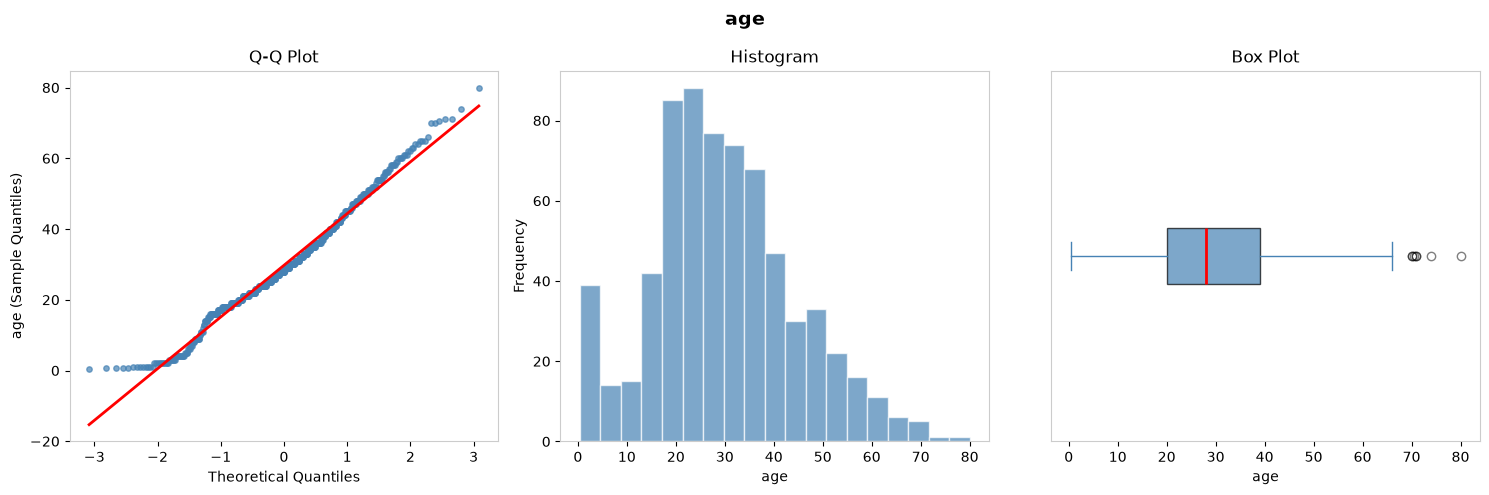

Column: age
Test: Shapiro-Wilk
Test Statistic: 0.9831, p-value: 0.0000
Result: Based on the Shapiro-Wilk test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


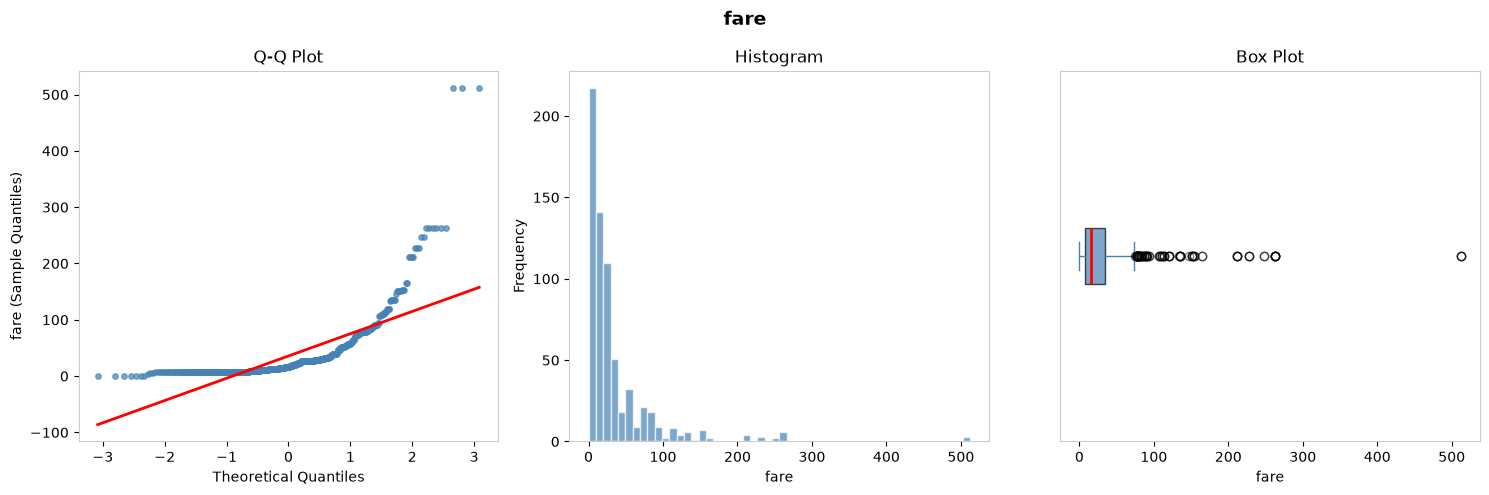

Column: fare
Test: Shapiro-Wilk
Test Statistic: 0.5347, p-value: 0.0000
Result: Based on the Shapiro-Wilk test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Note: The results above are based on statistical tests only. 
Please verify using the visuals before making a final decision. 
To manually set normality, pass result_dict={'col_name': 'Normal/Non-normal'} 
to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Columns flagged as Non-normal by the test — please verify visually: ['age', 'fare']


['age', 'fare']

In [11]:
eda.check_num(plot=True)

# 9. Distribution-Aware Numerical Profiling: Median vs. Mean
In this step, we execute the `num_summary()` method by passing our `result_dict` with **'Non-normal'** labels for both 'age' and 'fare'. This triggers a specialized reporting mode in our toolkit:
* **Central Tendency shift**: Instead of relying on the Mean, the analysis highlights the **Median**, which provides a more realistic "typical" passenger age and ticket price in a skewed dataset.
* **Spread Analysis**: The toolkit focuses on the **Interquartile Range (IQR)** rather than Standard Deviation, protecting our insights from being distorted by the extreme ticket prices of first-class passengers.
* **Ready for Outliers**: This step formally establishes the baseline for our next phase—outlier management—ensuring that capping or removal is based on non-parametric boundaries.

In [12]:
eda.num_summary(result_dict={'age':'Non-normal','fare':'Non-normal'})

,Column,Result
0,age,Non-normal
1,fare,Non-normal


# 10. Robust Outlier Mitigation: Winsorization of Passenger Data
In this step, we execute the `check_outlier()` method with `cap=True` to handle extreme values in the **'age'** and **'fare'** columns. Since we previously identified these distributions as **'Non-normal'**, the toolkit automatically applies the **Interquartile Range (IQR)** method for capping. Instead of removing the records of wealthy first-class passengers or very elderly individuals, we replace values beyond the upper and lower whiskers with the boundary limits. This "Winsorization" process ensures that we retain the valuable survival status of every passenger while neutralizing the disproportionate statistical weight of extreme ticket costs.

In [13]:
eda.check_outlier(cap=True)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                            Outlier Detection                                                                             
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Column: age | Method: IQR | Outliers: 7 (1.04%)
  → 'age' capped at [-8.5000, 67.5000]
Column: fare | Method: IQR | Outliers: 87 (12.91%)
  → 'fare' capped at [-31.7516, 74.3860]


({'age': {'method': 'IQR',
   'outlier_count': 7,
   'outlier_ratio': 0.010385756676557863},
  'fare': {'method': 'IQR',
   'outlier_count': 87,
   'outlier_ratio': 0.129080118694362}},
      survived  pclass     sex   age  sibsp  parch     fare embarked   class    who  adult_male  embark_town alive  alone
 0           0       3    male  22.0      1      0   7.2500        S   Third    man        True  Southampton    no  False
 1           1       1  female  38.0      1      0  71.2833        C   First  woman       False    Cherbourg   yes  False
 2           1       3  female  26.0      0      0   7.9250        S   Third  woman       False  Southampton   yes   True
 3           1       1  female  35.0      1      0  53.1000        S   First  woman       False  Southampton   yes  False
 4           0       3    male  35.0      0      0   8.0500        S   Third    man        True  Southampton    no   True
 ..        ...     ...     ...   ...    ...    ...      ...      ...     ...    ..

# 11. Post-Capping Distribution Re-validation
Since the capping process (Winsorization) artificially pulls extreme values toward the boundaries, it inherently alters the distribution's shape and statistical moments. In this step, we re-run the `check_num()` method to visually confirm how the removal of extreme 'fare' and 'age' values has impacted the histograms and Q-Q plots. Following this, we update our `result_dict` and pass it to `num_summary()` once more. This ensures that our final baseline for numerical data is representative of the cleaned, capped values, providing a more stable foundation for the upcoming bivariate survival analysis.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                        Numerical Variable Summary                                                                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


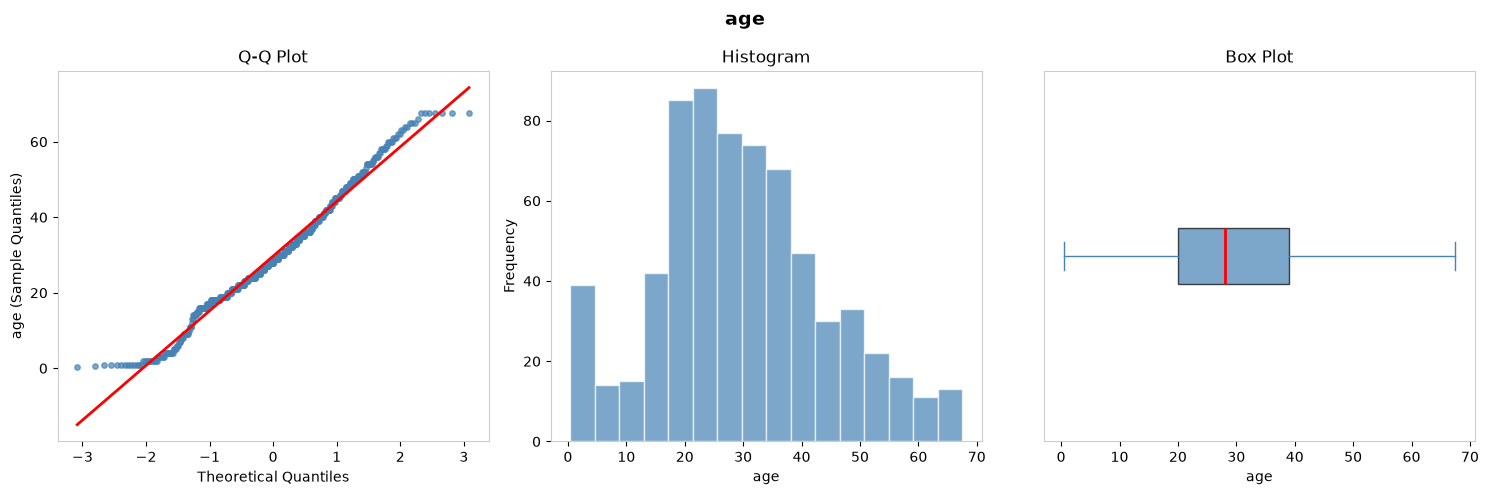

Column: age
Test: Shapiro-Wilk
Test Statistic: 0.9826, p-value: 0.0000
Result: Based on the Shapiro-Wilk test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


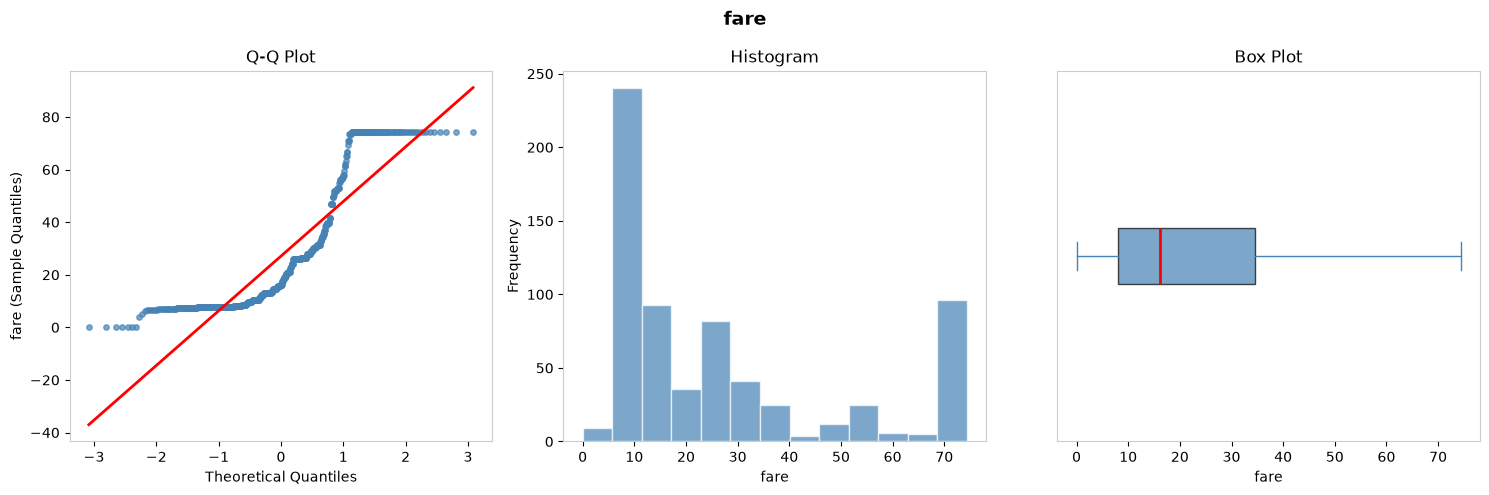

Column: fare
Test: Shapiro-Wilk
Test Statistic: 0.7908, p-value: 0.0000
Result: Based on the Shapiro-Wilk test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Note: The results above are based on statistical tests only. 
Please verify using the visuals before making a final decision. 
To manually set normality, pass result_dict={'col_name': 'Normal/Non-normal'} 
to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Columns flagged as Non-normal by the test — please verify visually: ['age', 'fare']


['age', 'fare']

In [14]:
eda.check_num(plot=True)

In [15]:
eda.num_summary(result_dict={'age':'Non-normal','fare':'Non-normal'})

,Column,Result
0,age,Non-normal
1,fare,Non-normal


# 12. Categorical Variable Profiling: The Demographics of Survival
With the numerical cleaning and re-validation complete, we pivot to analyzing the qualitative dimensions of the Titanic dataset using the `cat_summary()` method. In the context of the Titanic, this step is vital for understanding the distribution of features like **'sex'**, **'pclass'**, and **'embarked'**. The automated report provides:
* **Frequency Distribution**: Calculating the exact number and percentage of passengers in each category (e.g., Male vs. Female ratio).
* **Class Imbalance Detection**: Identifying if certain groups (like 3rd class passengers) dominate the dataset, which is a critical precursor to understanding survival bias.
* **Visual Proportionality**: Generating bar charts to provide an immediate visual sense of the passenger makeup before we link these categories to the 'survived' target.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                       Categorical Variable Summary                                                                       
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Column: sex
        Count      Ratio
sex                     
male      421  62.462908
female    253  37.537092


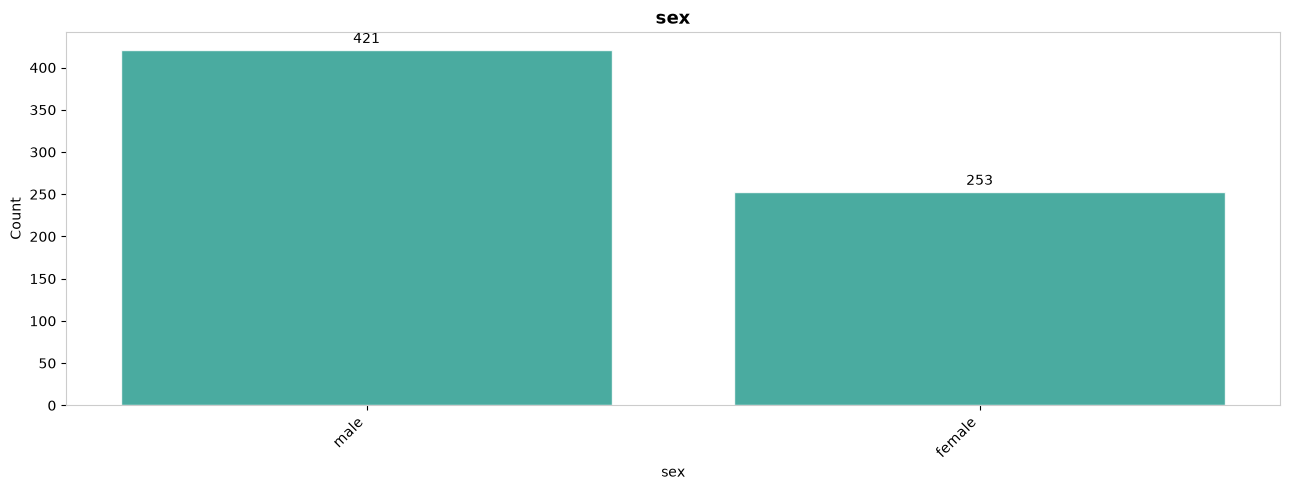


Column: embarked
          Count      Ratio
embarked                  
S           518  76.854599
C           128  18.991098
Q            28   4.154303


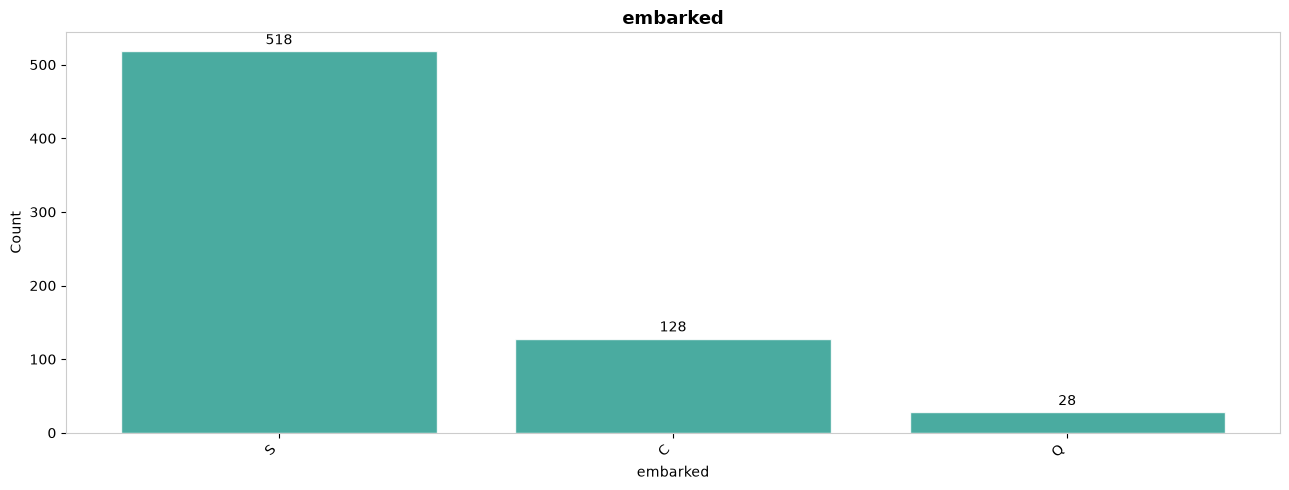


Column: class
        Count      Ratio
class                   
Third     334  49.554896
First     182  27.002967
Second    158  23.442136


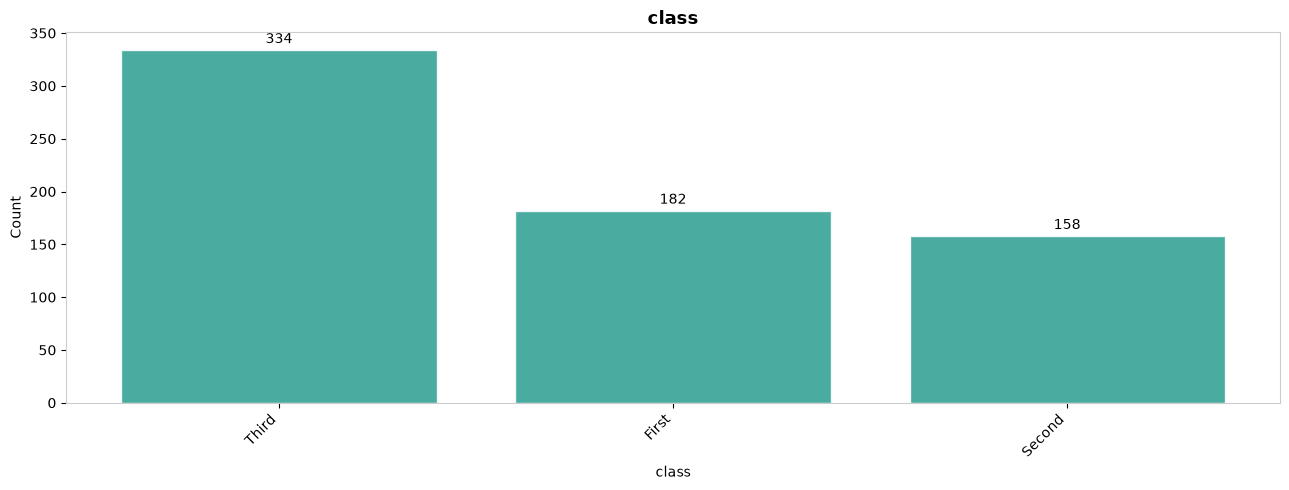


Column: who
       Count      Ratio
who                    
man      381  56.528190
woman    211  31.305638
child     82  12.166172


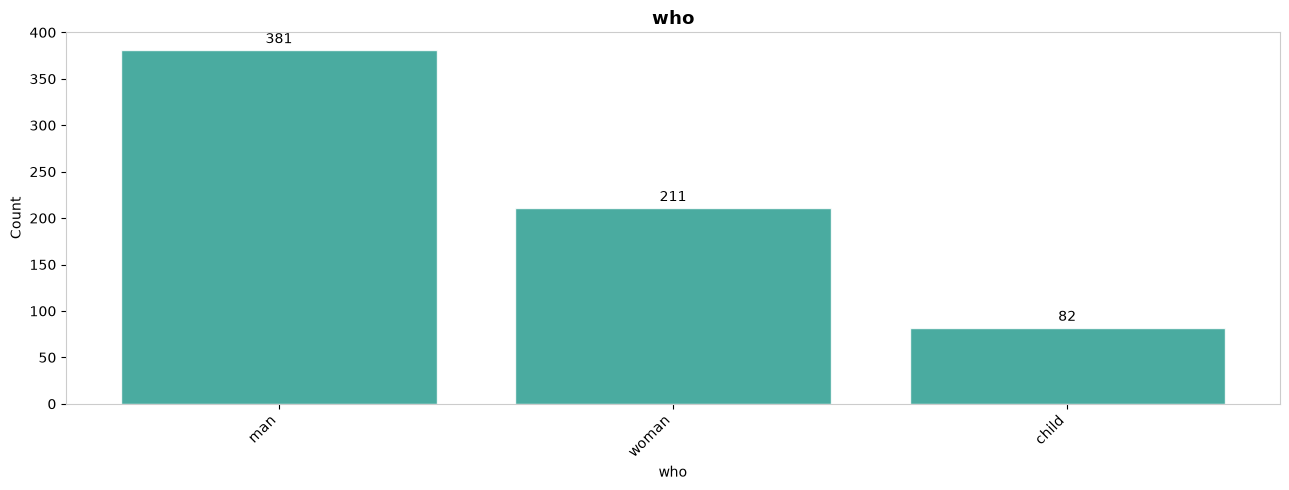


Column: adult_male
            Count     Ratio
adult_male                 
True          381  56.52819
False         293  43.47181


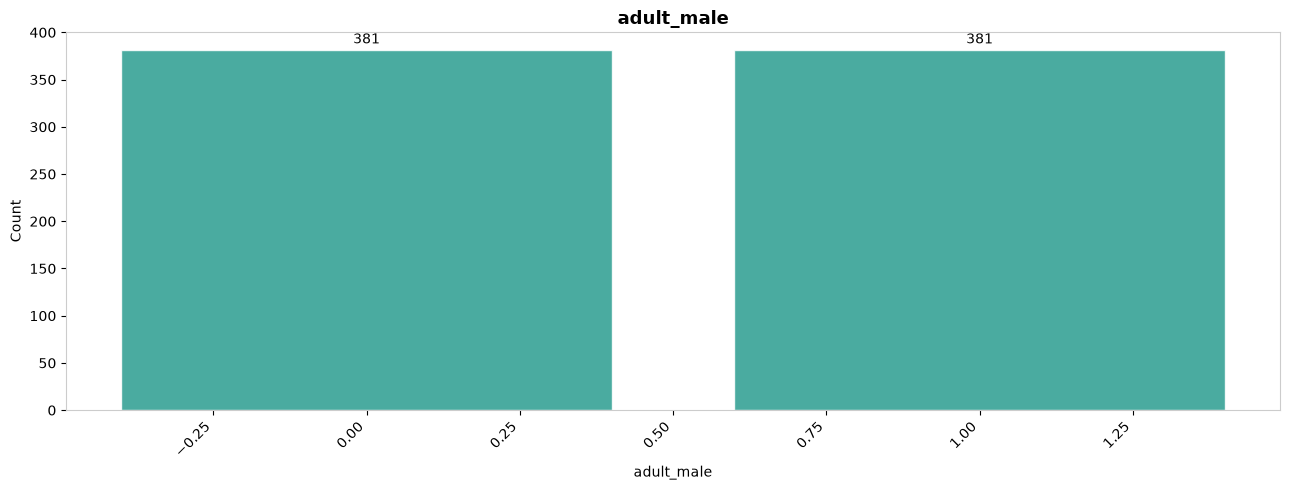


Column: embark_town
             Count      Ratio
embark_town                  
Southampton    518  76.854599
Cherbourg      128  18.991098
Queenstown      28   4.154303


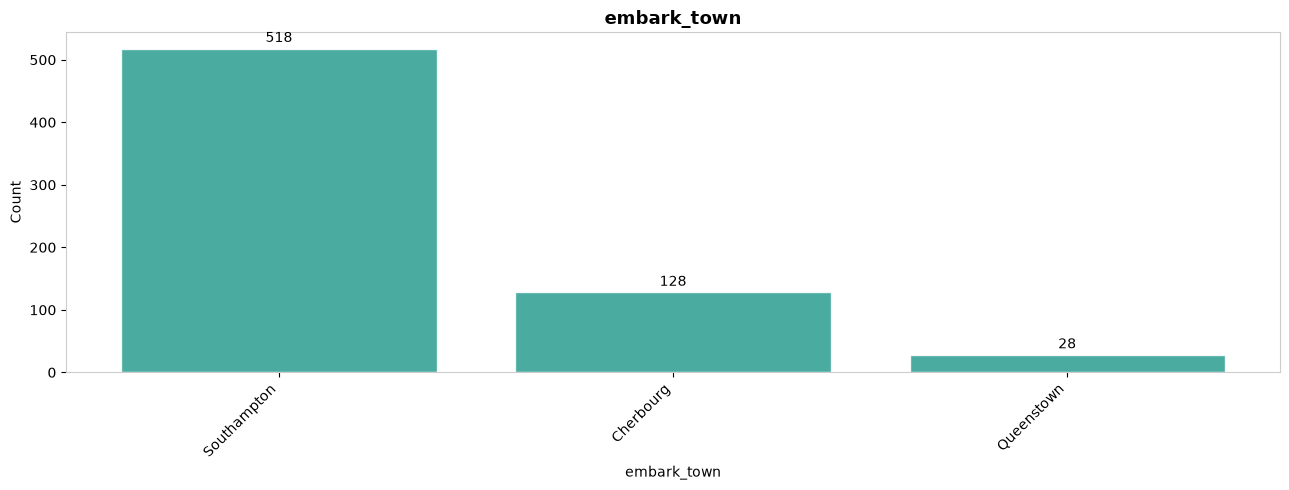


Column: alive
       Count      Ratio
alive                  
no       393  58.308605
yes      281  41.691395


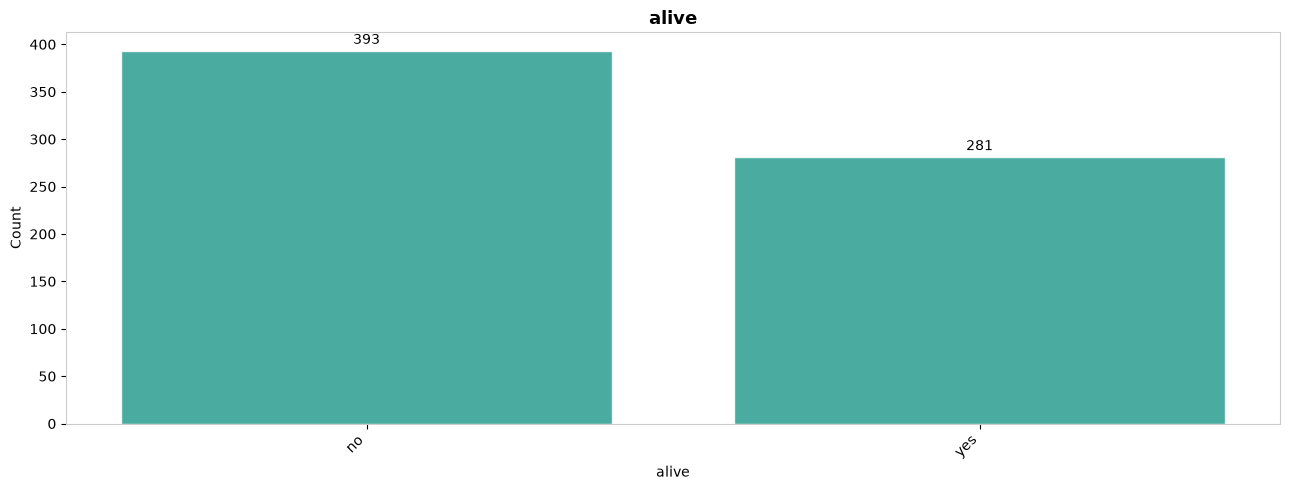


Column: alone
       Count      Ratio
alone                  
True     367  54.451039
False    307  45.548961


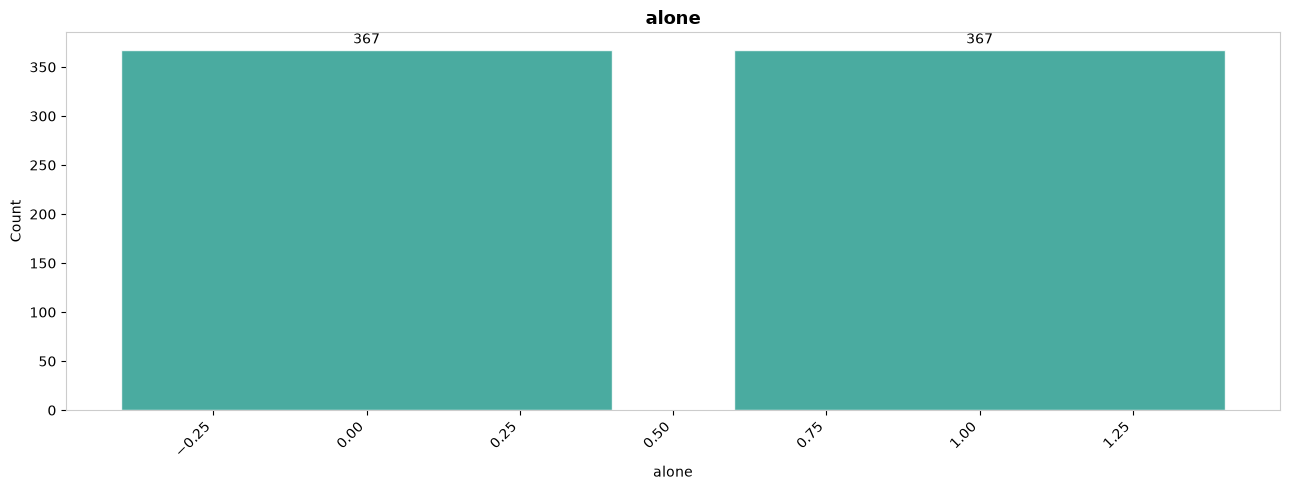


Column: survived
          Count      Ratio
survived                  
0           393  58.308605
1           281  41.691395


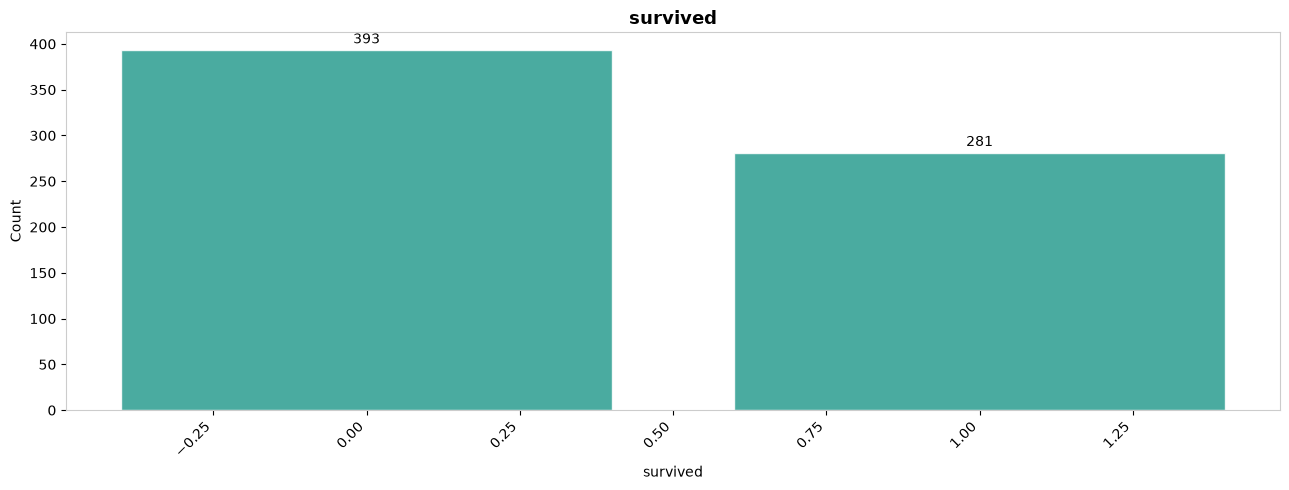


Column: pclass
        Count      Ratio
pclass                  
3         334  49.554896
1         182  27.002967
2         158  23.442136


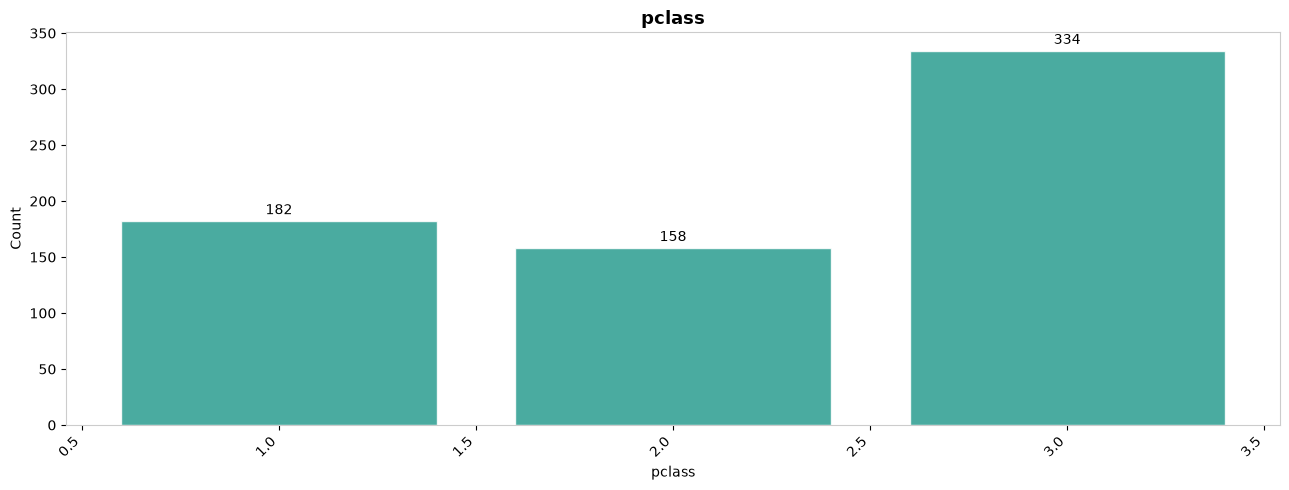


Column: sibsp
       Count      Ratio
sibsp                  
0        434  64.391691
1        181  26.854599
2         24   3.560831
4         18   2.670623
3         12   1.780415
5          5   0.741840


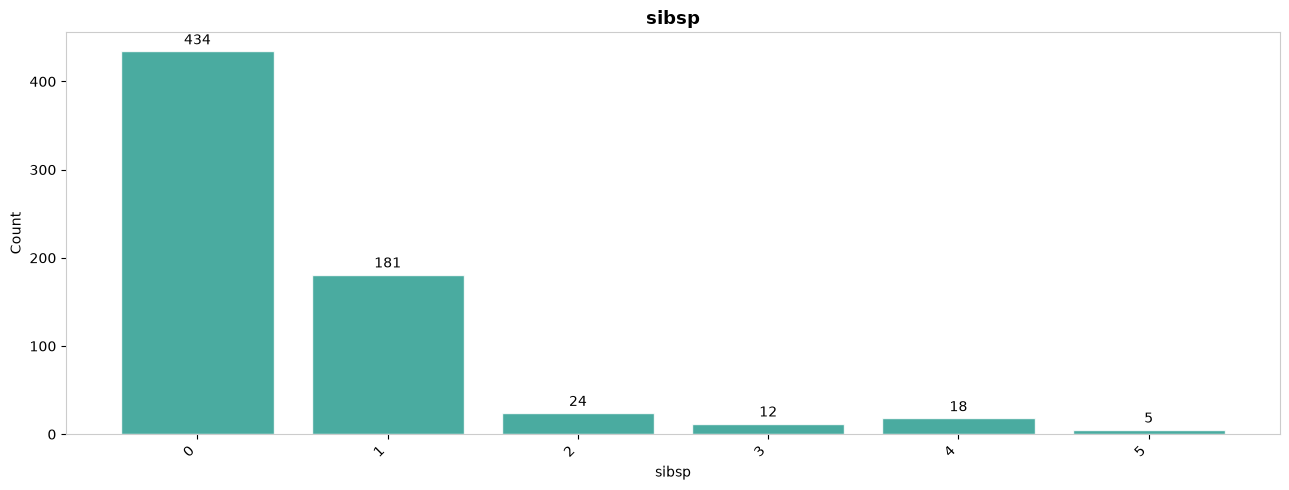


Column: parch
       Count      Ratio
parch                  
0        482  71.513353
1        109  16.172107
2         68  10.089021
5          5   0.741840
3          5   0.741840
4          4   0.593472
6          1   0.148368


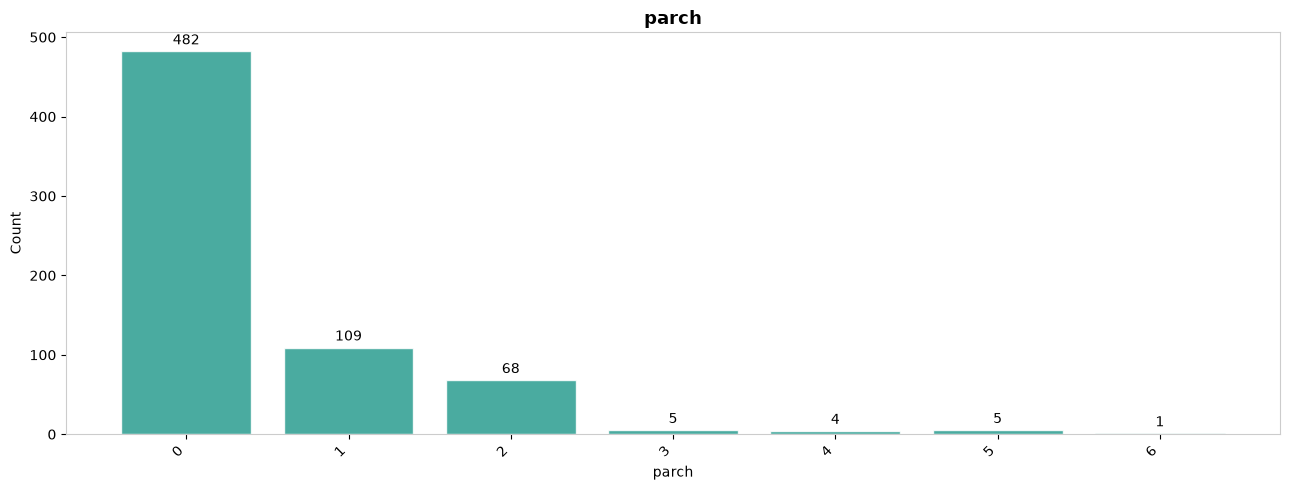

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [16]:
eda.cat_summary(plot=True)

# 13. Categorical Impact on Survival: Bivariate Analysis
In this step, we execute the `target_summary_with_cat()` method to analyze the relationship between categorical features and the survival status of passengers. This is the core of our Titanic EDA, where we quantify the "survival rate" for each group. The report provides:
* **Target Mean by Category**: For example, calculating the survival percentage for 'females' vs. 'males' or '1st class' vs. '3rd class'.
* **Probability Disparity**: Identifying which categories had a significantly higher or lower chance of survival, confirming historical patterns like the "women and children first" protocol.
* **Group Frequency**: Showing the sample size for each group to ensure that high survival rates are statistically representative and not just based on a few individuals.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                Target Analysis with Categorical Variables                                                                
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


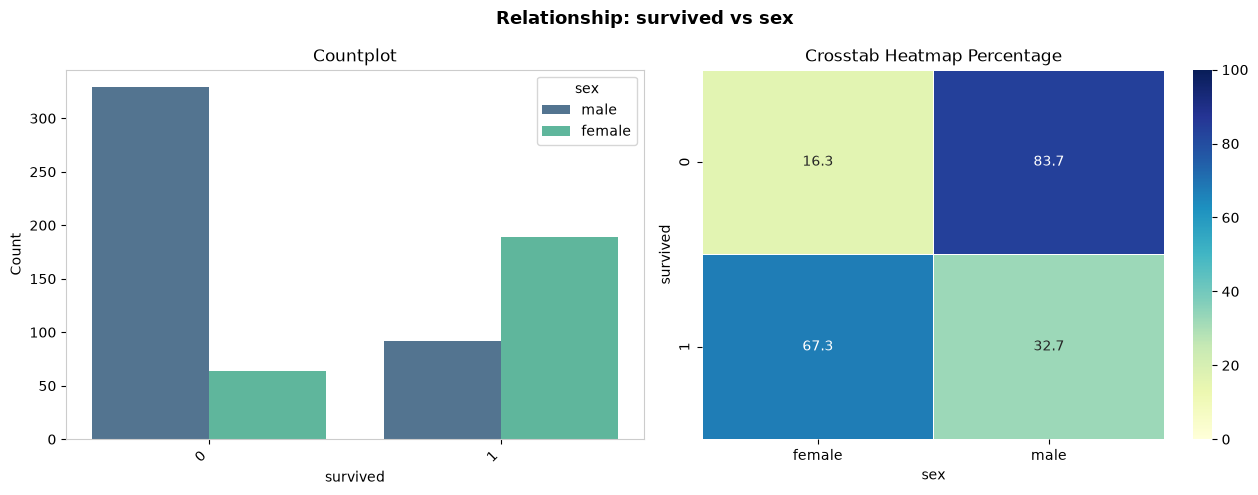


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 179.4121
p-value = 0.000000
df      = 1

Expected Values:
sex       female   male
survived               
0          147.5  245.5
1          105.5  175.5 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and sex (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                    

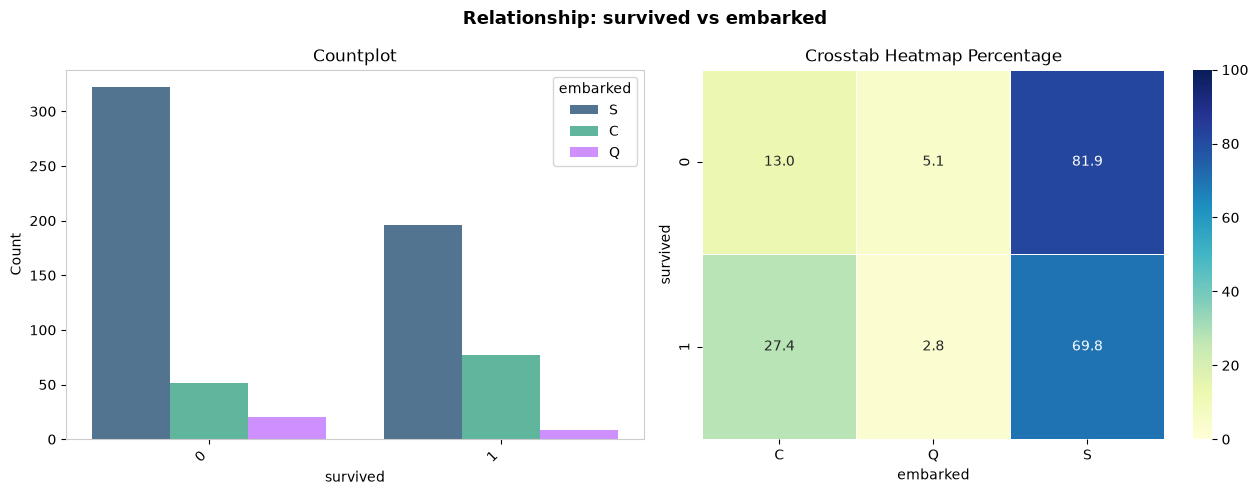


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 23.0993
p-value = 0.000010
df      = 2

Expected Values:
embarked     C     Q      S
survived                   
0         74.6  16.3  302.0
1         53.4  11.7  216.0 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and embarked (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                

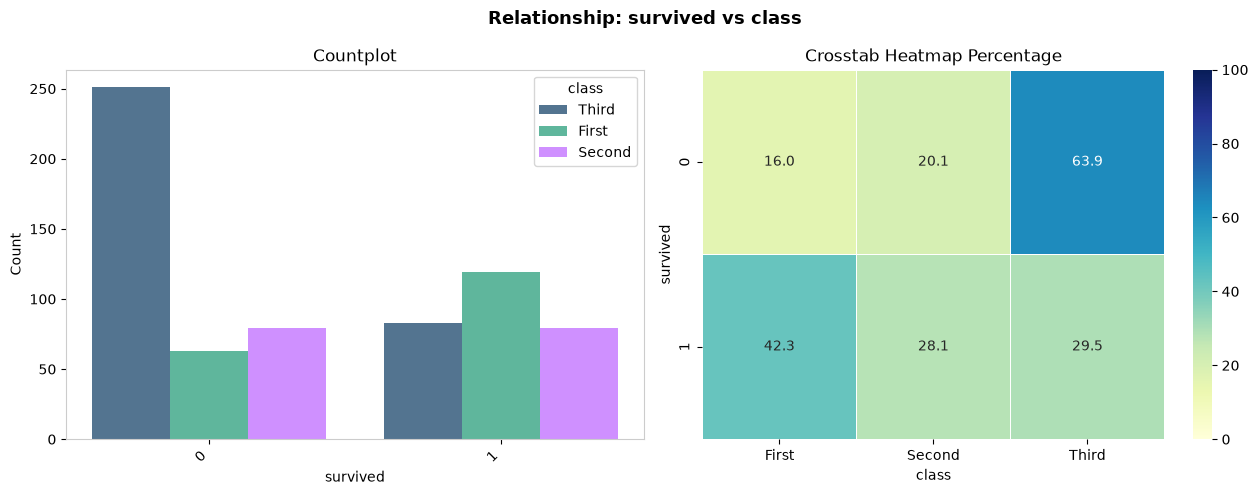


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 85.4829
p-value = 0.000000
df      = 2

Expected Values:
class     First  Second  Third
survived                      
0         106.1    92.1  194.8
1          75.9    65.9  139.2 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and class (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                       

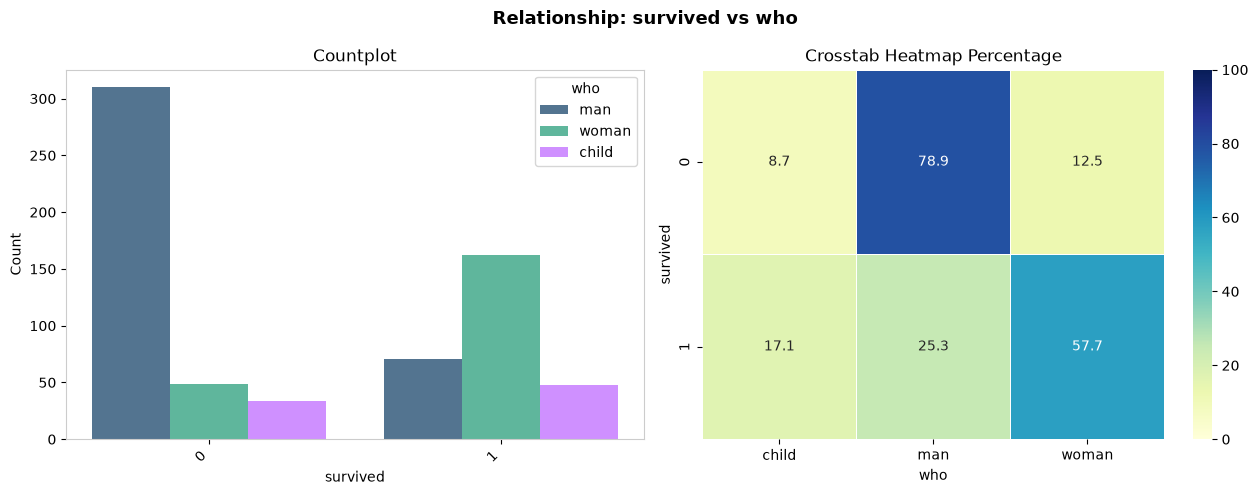


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 199.7347
p-value = 0.000000
df      = 2

Expected Values:
who       child    man  woman
survived                     
0          47.8  222.2  123.0
1          34.2  158.8   88.0 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and who (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                            

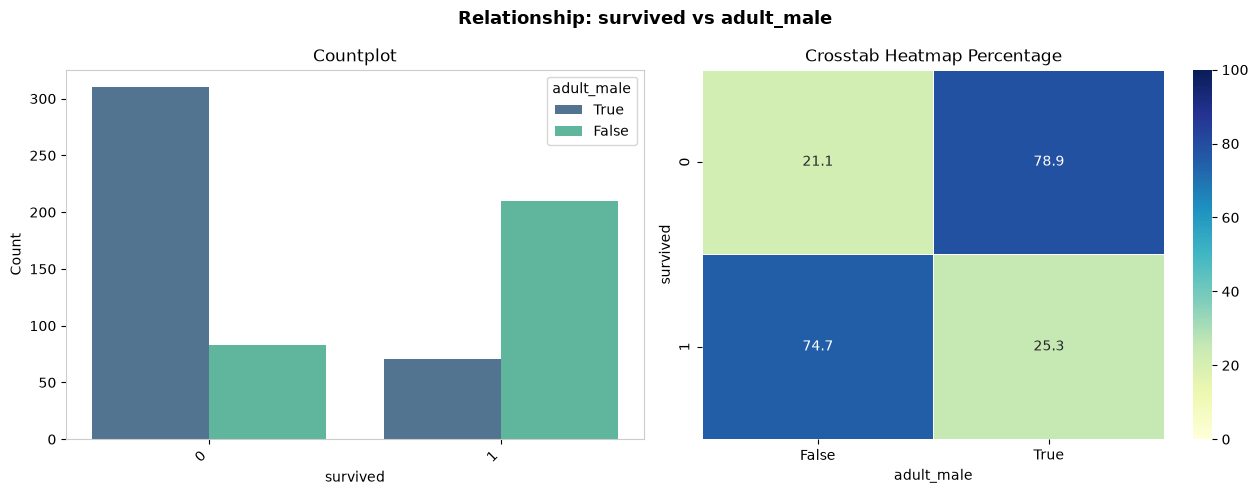


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 189.4770
p-value = 0.000000
df      = 1

Expected Values:
adult_male  False  True 
survived                
0           170.8  222.2
1           122.2  158.8 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and adult_male (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                         

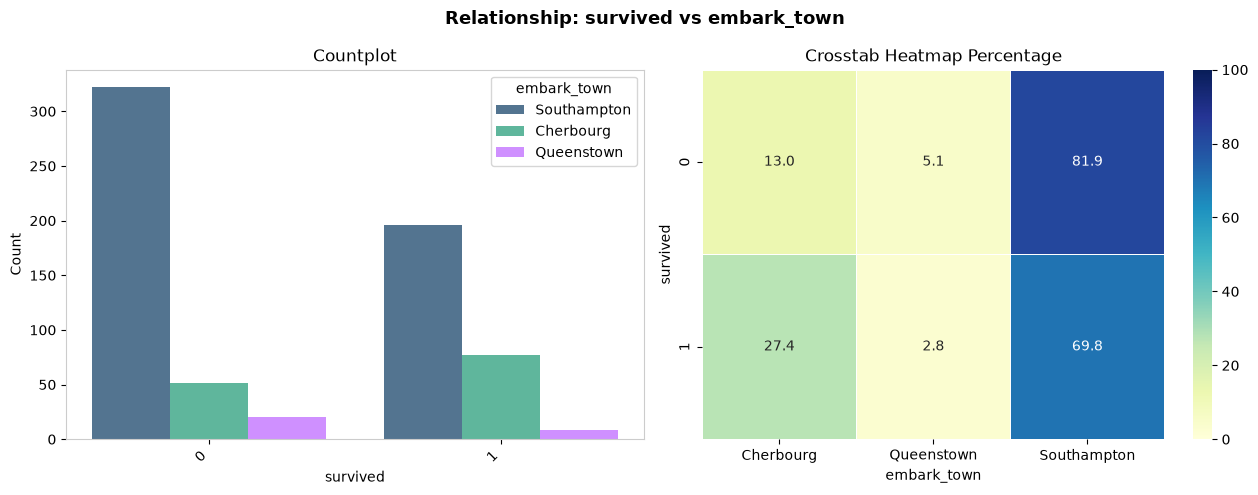


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 23.0993
p-value = 0.000010
df      = 2

Expected Values:
embark_town  Cherbourg  Queenstown  Southampton
survived                                       
0                 74.6        16.3        302.0
1                 53.4        11.7        216.0 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and embark_town (p < 0.05)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

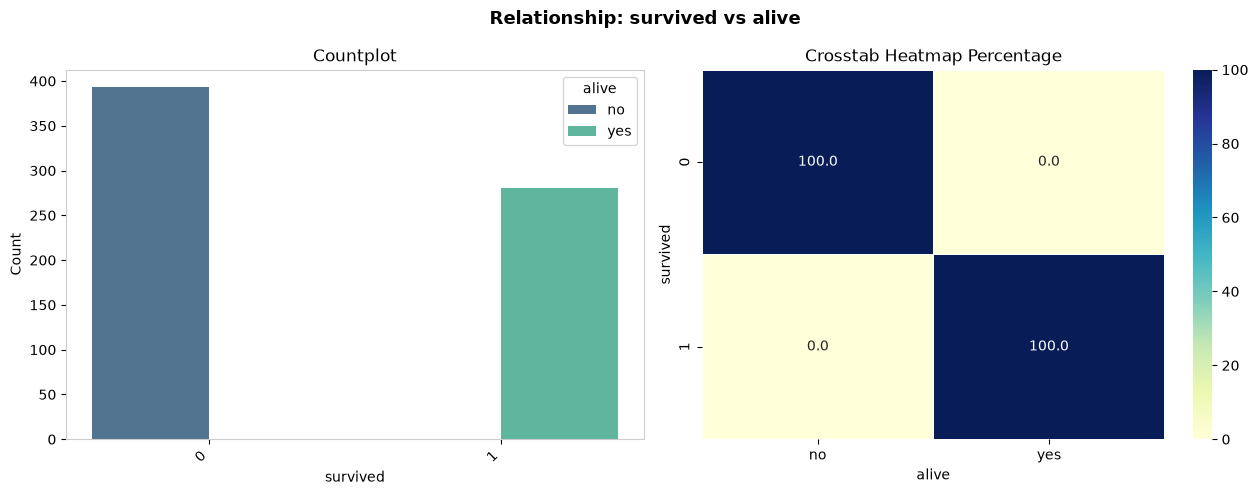


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 669.8927
p-value = 0.000000
df      = 1

Expected Values:
alive        no    yes
survived              
0         229.2  163.8
1         163.8  117.2 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and alive (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                      

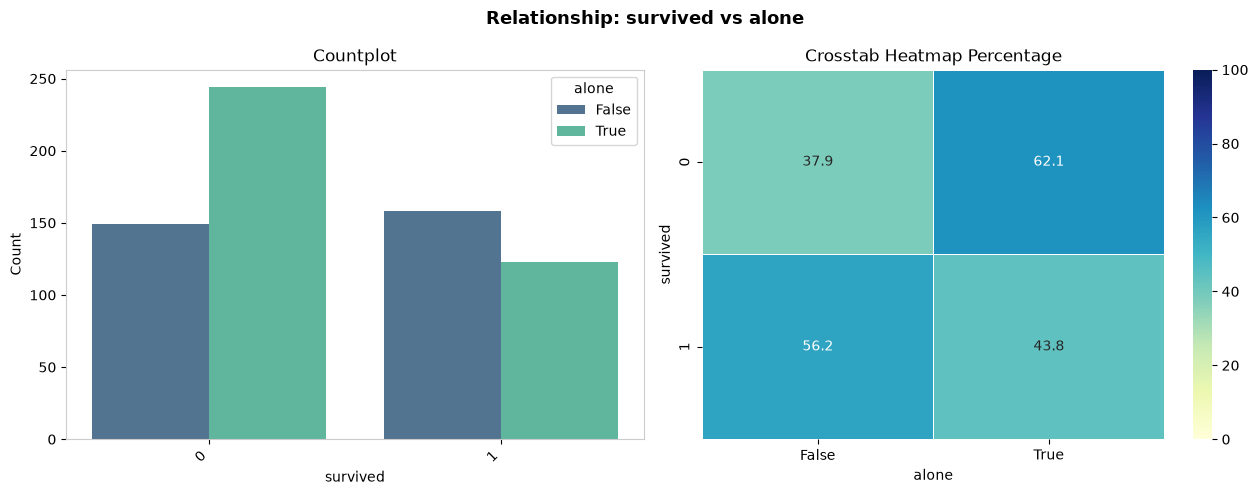


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 21.4259
p-value = 0.000004
df      = 1

Expected Values:
alone     False  True 
survived              
0         179.0  214.0
1         128.0  153.0 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and alone (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                       

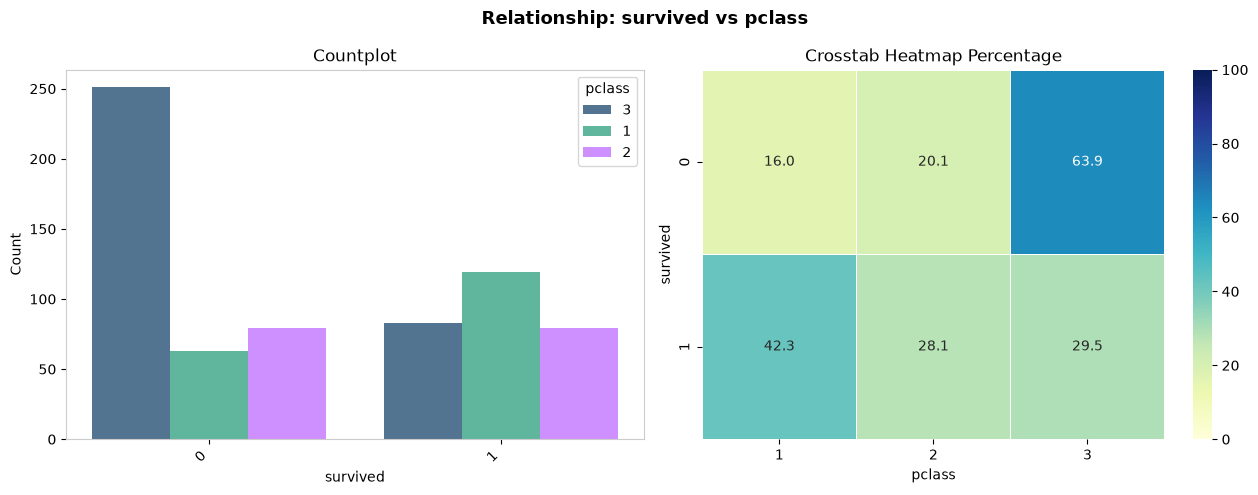


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 85.4829
p-value = 0.000000
df      = 2

Expected Values:
pclass        1     2      3
survived                    
0         106.1  92.1  194.8
1          75.9  65.9  139.2 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and pclass (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                              

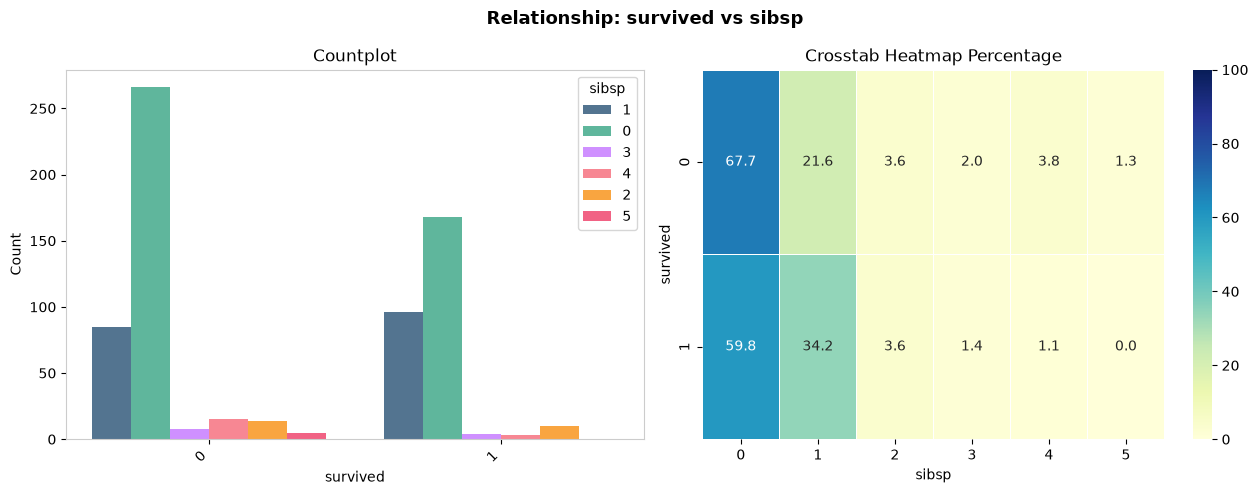


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 19.7311
p-value = 0.001404
df      = 5

Expected Values:
sibsp         0      1     2    3     4    5
survived                                    
0         253.1  105.5  14.0  7.0  10.5  2.9
1         180.9   75.5  10.0  5.0   7.5  2.1 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and sibsp (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

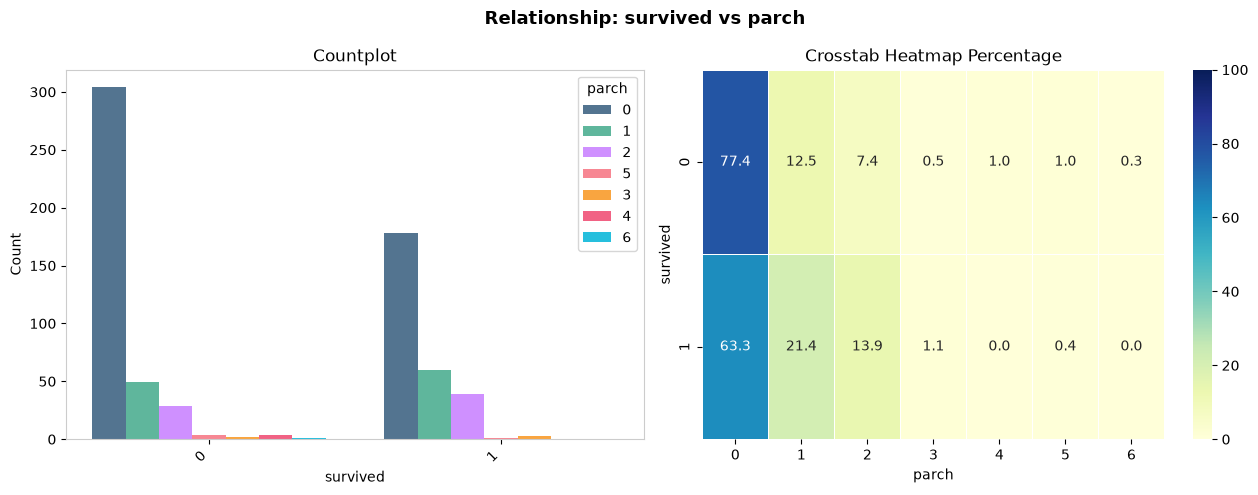


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 24.5861
p-value = 0.000407
df      = 6

Expected Values:
parch         0     1     2    3    4    5    6
survived                                       
0         281.0  63.6  39.6  2.9  2.3  2.9  0.6
1         201.0  45.4  28.4  2.1  1.7  2.1  0.4 

Result:

→ H₀ REJECTED: There is a significant relationship between survived and parch (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [17]:
eda.target_summary_with_cat(plot=True)

# 14. Numerical Correlation with Survival: Analyzing Age and Fare
In this step, we execute the `target_summary_with_num()` method to examine how continuous variables influence the survival outcome. This bivariate analysis bridges the gap between raw numbers and survival probability. The report provides:
* **Mean and Median by Target**: Comparing the average ticket price ('fare') and 'age' for survivors (1) versus those who did not survive (0). 
* **Economic Survival Gap**: Quantifying if higher ticket costs directly correlate with a higher survival rate, providing numerical evidence for the "class-based" survival disparity.
* **Age Impact**: Analyzing the age distribution of survivors to see if the "children first" policy is reflected in the numerical averages.

This analysis is essential for identifying which numerical features will carry the most predictive weight in a future machine learning model.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                 Target Analysis with Numerical Variables                                                                 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
               mean median count
                age    age   age
survived                        
0         30.819338   29.0   393
1         28.140285   28.0   281


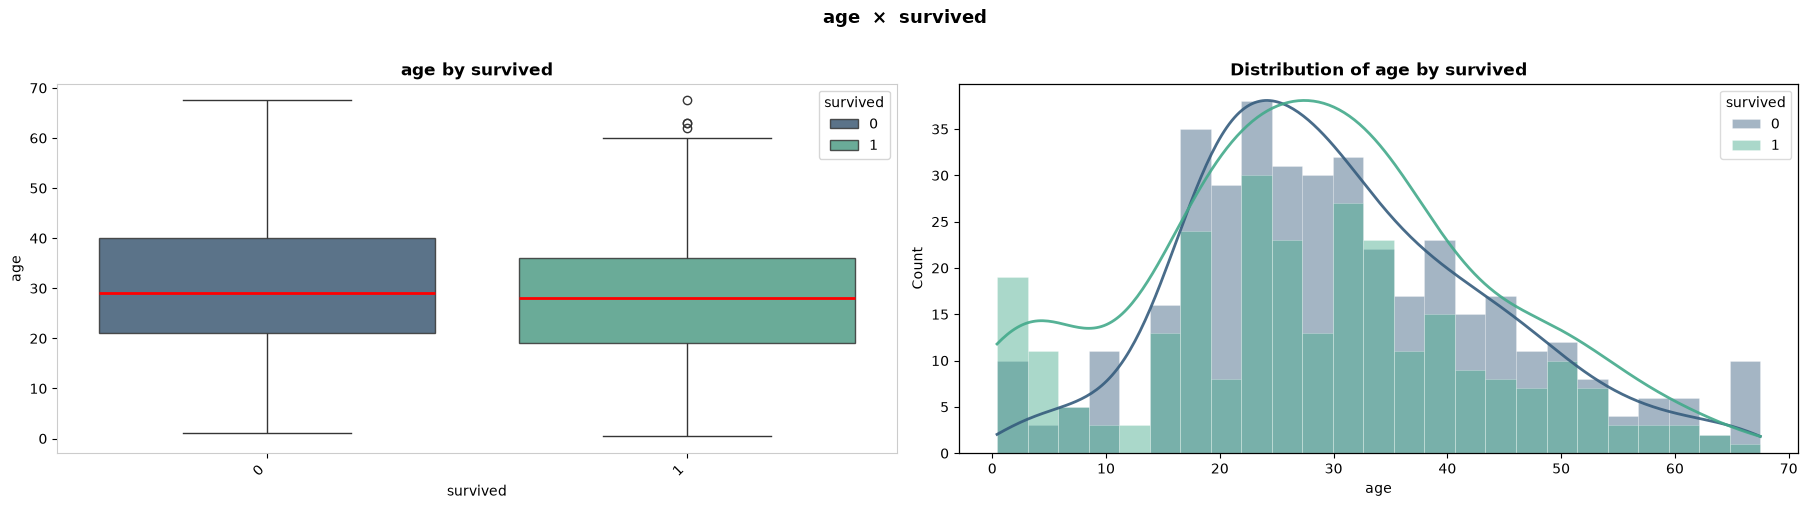


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.077748.
 H₀ ACCEPTED: No significant difference.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
               mean median count
               fare   fare  fare
survived                        
0         20.933793  13.00   393
1         35.689358  26.25   281


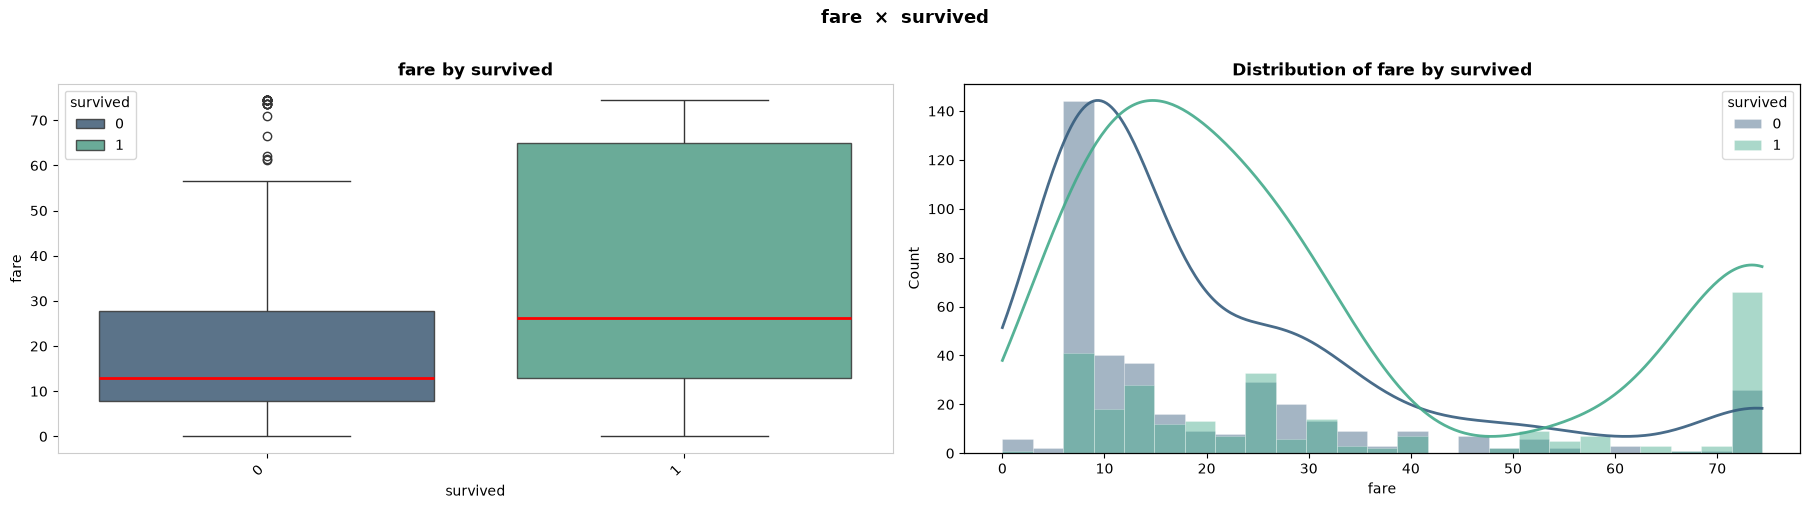


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
Effect size r = 0.3203/Medium — the difference is both statistically significant and practically meaningful.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [18]:
eda.target_summary_with_num(plot=True)